# 🧹 Data Cleaning & Preprocessing

Raw datasets often contain invalid values, inconsistencies, and extreme observations that can negatively affect machine learning models.

The objective of this notebook is to clean the dataset and prepare it for feature engineering.

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")

# Initial Dataset Shape

In [3]:
print(train_df.shape)

(1458644, 11)


# 1. Datetime Conversion

The pickup and dropoff timestamps are currently stored as object data types.

They will be converted into datetime format to support temporal feature engineering.

In [4]:
train_df["pickup_datetime"] = pd.to_datetime(train_df["pickup_datetime"])

train_df["dropoff_datetime"] = pd.to_datetime(train_df["dropoff_datetime"])

In [5]:
train_df.dtypes

id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

### Observation

Both datetime columns have been successfully converted to datetime format.

# 2. Passenger Count Cleaning

In [6]:
train_df["passenger_count"].value_counts().sort_index()

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64

In [7]:
invalid_passengers = train_df[train_df["passenger_count"] == 0]

print("Invalid Passenger Records:", len(invalid_passengers))

Invalid Passenger Records: 60


In [8]:
train_df = train_df[train_df["passenger_count"] > 0]

### Observation

Passenger count equal to zero is not meaningful for taxi trips.

These records were removed.

# 3. Trip Duration Cleaning

In [9]:
train_df["trip_duration"].describe()

count    1.458584e+06
mean     9.594611e+02
std      5.237064e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

The dataset contains extremely long taxi trips that are unrealistic.

Instead of immediately removing them, we first visualize their distribution.

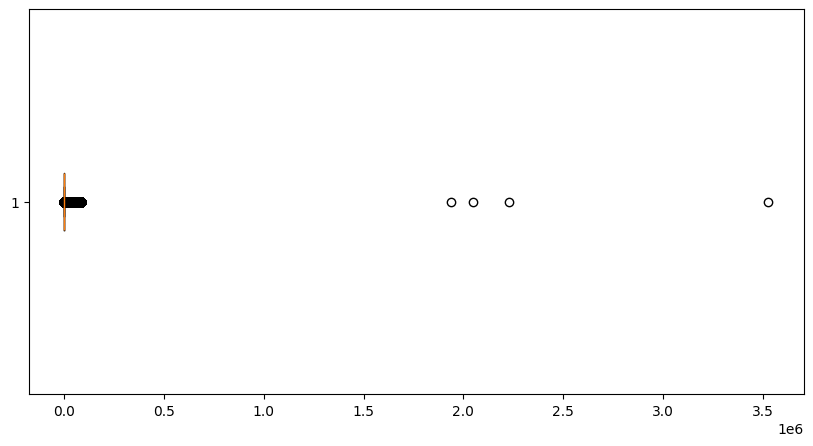

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.boxplot(train_df["trip_duration"], vert=False)

plt.show()

In [11]:
Q1 = train_df["trip_duration"].quantile(0.25)

Q3 = train_df["trip_duration"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print(lower, upper)

-620.0 2092.0


In [12]:
train_df = train_df[
    (train_df["trip_duration"] >= lower) &
    (train_df["trip_duration"] <= upper)
]

### Observation

Extreme outliers in the target variable were removed using the Interquartile Range (IQR) method.

# 4. Coordinate Validation

In [13]:
train_df.describe()[[
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]]

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,1.384368e+06,1.384368e+06,1.384368e+06,1.384368e+06
mean,-7.397673e+01,4.075224e+01,-7.397494e+01,4.075287e+01
min,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01
25%,-7.399203e+01,4.073819e+01,-7.399140e+01,4.073706e+01
50%,-7.398201e+01,4.075438e+01,-7.397998e+01,4.075485e+01
75%,-7.396843e+01,4.076829e+01,-7.396388e+01,4.077006e+01
max,-6.133553e+01,5.188108e+01,-6.133553e+01,4.391176e+01
std,6.836680e-02,3.094036e-02,6.913025e-02,3.380720e-02


In [14]:
train_df = train_df[
    train_df["pickup_longitude"].between(-75, -73)
]

train_df = train_df[
    train_df["dropoff_longitude"].between(-75, -73)
]

train_df = train_df[
    train_df["pickup_latitude"].between(40, 42)
]

train_df = train_df[
    train_df["dropoff_latitude"].between(40, 42)
]

### Observation

Trips outside the expected New York City geographical boundaries were removed.

# 5. Final Dataset Summary

In [16]:
print(train_df.shape)

train_df.info()

(1384331, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 1384331 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1384331 non-null  object        
 1   vendor_id           1384331 non-null  int64         
 2   pickup_datetime     1384331 non-null  datetime64[ns]
 3   dropoff_datetime    1384331 non-null  datetime64[ns]
 4   passenger_count     1384331 non-null  int64         
 5   pickup_longitude    1384331 non-null  float64       
 6   pickup_latitude     1384331 non-null  float64       
 7   dropoff_longitude   1384331 non-null  float64       
 8   dropoff_latitude    1384331 non-null  float64       
 9   store_and_fwd_flag  1384331 non-null  object        
 10  trip_duration       1384331 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 126.7+ MB


# 6. Save Clean Dataset

The cleaned dataset will be stored for feature engineering.

In [17]:
train_df.to_csv(
    "../data/processed/train_clean.csv",
    index=False
)

# Conclusion

In this notebook:

- Converted datetime columns
- Removed invalid passenger counts
- Removed unrealistic trip durations
- Removed GPS anomalies
- Generated a cleaned dataset ready for feature engineering

The next notebook focuses on creating meaningful features such as pickup hour, weekday, Haversine distance, Manhattan distance, and traffic-related indicators.

I actually wouldn't remove outliers immediately using IQR just because it's a common technique.

For this dataset, trip duration is naturally right-skewed, and some long trips can be legitimate. Before deleting records, we should inspect the distribution (possibly after a log transformation) and use domain knowledge—for example, removing clearly impossible trips or GPS errors—rather than automatically discarding everything outside the IQR.

So when we build this notebook together, we'll revisit the outlier strategy and make it evidence-based rather than applying IQR by default. That's a stronger approach and one you can confidently defend in an interview.